# Analisis Exploratorio de Datos | Prediccion Fallo Cardiaco

> Elaborado por Nino Cabrera y Tiffany Mendoza

## Introducción y contexto

### Objetivo del análisis

#### Objetivo general

Construir un modelo de clasificación binaria para predecir si un paciente tiene riesgo de sufrir una enfermedad cardíaca, aplicando prácticas de MLOps en un entorno local con FastAPI, Docker y monitoreo con Evidently.

#### Objetivos específicos

- Explorar y comprender la estructura del dataset, identificando la distribución del target, valores faltantes y relaciones entre variables clínicas relevantes
- Preprocesar los datos usando scikit-learn con Pipelines, evitando data leakage
- Entrenar múltiples modelos con GridSearchCV y comparar su desempeño usando AUC y Accuracy
- Desplegar el mejor modelo como API REST con FastAPI, contenerizada con Docker
- Monitorear deriva de datos entre entrenamiento y predicción usando Evidently

### Contexto

El dataset Heart Failure Prediction fue publicado en Kaggle y contiene registros clínicos de pacientes con 11 variables como presión sanguínea, colesterol, glucosa en ayunas, edad y tipo de dolor en el pecho, entre otras. El objetivo es predecir si un paciente presenta enfermedad cardíaca (`HeartDisease = 1`) o no (`HeartDisease = 0`). Las enfermedades cardiovasculares son la principal causa de muerte en el mundo según la OMS, por lo que detectarlas a tiempo es fundamental para evitar complicaciones graves.

## Dimensiones de datos del conjunto

Para comenzar, es importante saber las dimensiones exactas del dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_selection import mutual_info_classif
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv("../data/heart.csv")
pd.options.display.float_format = '{:,.2f}'.format
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    str    
 2   ChestPainType   918 non-null    str    
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    str    
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    str    
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    str    
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), str(5)
memory usage: 86.2 KB
None


El dataset original cuenta con 918 registros y 12 columnas

### Variable objetivo

Se usara como variable objetivo `HeartDisease` para predecir si un paciente tiene riesgo de sufrir una falla cardiaca o no (HeartDisease = 1 o 0)

In [2]:
print(df["HeartDisease"].value_counts())
print(df["HeartDisease"].value_counts(normalize=True) * 100)

HeartDisease
1    508
0    410
Name: count, dtype: int64
HeartDisease
1   55.34
0   44.66
Name: proportion, dtype: float64


La distribución de la variable objetivo HeartDisease muestra que el 55.34% de los pacientes en el dataset presentan enfermedad cardíaca (1), mientras que el 44.66% no la presentan (0)

## Inspeccion general 

En esta seccion, se podra ver las primeras filas del dataset, que tipos de tados y un resumen estadistico basico.

In [3]:
print(df.head())

   Age Sex ChestPainType  RestingBP  Cholesterol  FastingBS RestingECG  MaxHR  \
0   40   M           ATA        140          289          0     Normal    172   
1   49   F           NAP        160          180          0     Normal    156   
2   37   M           ATA        130          283          0         ST     98   
3   48   F           ASY        138          214          0     Normal    108   
4   54   M           NAP        150          195          0     Normal    122   

  ExerciseAngina  Oldpeak ST_Slope  HeartDisease  
0              N     0.00       Up             0  
1              N     1.00     Flat             1  
2              N     0.00       Up             0  
3              Y     1.50     Flat             1  
4              N     0.00       Up             0  


### Valores faltantes
Se verificara los valores faltantes

In [4]:
faltantes = df.isnull().sum().sort_values(ascending=False)
porcentaje = (df.isnull().sum() / len(df) * 100).sort_values(ascending=False)
print(faltantes)
print(porcentaje)

Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64
Age              0.00
Sex              0.00
ChestPainType    0.00
RestingBP        0.00
Cholesterol      0.00
FastingBS        0.00
RestingECG       0.00
MaxHR            0.00
ExerciseAngina   0.00
Oldpeak          0.00
ST_Slope         0.00
HeartDisease     0.00
dtype: float64


Se puede ver como ninguna de las columnas dadas tiene valores faltantes.

### Medidas basicas 
Las medidas de tendencia central como la media, mediana, desviacion estandar y moda nos muestran como se deben comportar las variables numericas del dataset

In [5]:
display(df.describe().T)

,count,mean,std,min,25%,50%,75%,max
Age,918.00,53.51,9.43,28.00,47.00,54.00,60.00,77.00
RestingBP,918.00,132.40,18.51,0.00,120.00,130.00,140.00,200.00
Cholesterol,918.00,198.80,109.38,0.00,173.25,223.00,267.00,603.00
FastingBS,918.00,0.23,0.42,0.00,0.00,0.00,0.00,1.00
MaxHR,918.00,136.81,25.46,60.00,120.00,138.00,156.00,202.00
Oldpeak,918.00,0.89,1.07,-2.60,0.00,0.60,1.50,6.20
HeartDisease,918.00,0.55,0.50,0.00,0.00,1.00,1.00,1.00


 Se puede ver que el dataset cuenta con 7 variables numericas. La edad promedio es de 53 años con valores entre 28 y 77. La presion arterial en reposo tiene una media de 132.40, se puede ver como hay minimo de 0, lo que probablemente corresponde a un dato erroneo. El colesterol tambien se ve un minimo de 0 con una desviacion estandar alta de 109.3. La frecuencia cardiaca maxima (MaxHR) promedia 136.81 con rango entre 60 a 202. FastingBS es binaria (0 o 1). Finalmente, Oldpeak tiene valores que van desde -2.60 hasta 6.20 con una mediana de 0.60

#### Verificacion error 

In [6]:
print("RestingBP == 0:", (df["RestingBP"] == 0).sum())
print("Cholesterol == 0:", (df["Cholesterol"] == 0).sum())

RestingBP == 0: 1
Cholesterol == 0: 172


Debido a que el colesterol (Cholesterol) y la presion arterial en reposo (RestingBP) no pueden ser 0 porque es medicamente imposible, se tomara como un error. Se puede ver que como la presion arterial en reposo solo hay 1 valor con la presion arterial en 0 se puede borrar. Los 172 que estan en 0 del colesterol se imputaran con la mediana en el preprocesamiento

##### Eliminacion error RestingBP

In [7]:
df = df[df["RestingBP"] != 0].reset_index(drop=True)
print(f"Filas después de eliminar RestingBP == 0: {df.shape[0]}")

Filas después de eliminar RestingBP == 0: 917


El dataset queda con 917 filas

### Metricas de dispersion

Estas metricas de dispersion como  como el IQR (rango intercuartilico) permiten indentificar que tan dispersos estan los datos y deterctar posibles valores atipicos

In [8]:
cols = df.select_dtypes(include=np.number).columns.tolist()

Q1 = df[cols].quantile(0.25)
Q3 = df[cols].quantile(0.75)
IQR = Q3 - Q1

print(Q1)
print(Q3)
print(IQR)

Age             47.00
RestingBP      120.00
Cholesterol    174.00
FastingBS        0.00
MaxHR          120.00
Oldpeak          0.00
HeartDisease     0.00
Name: 0.25, dtype: float64
Age             60.00
RestingBP      140.00
Cholesterol    267.00
FastingBS        0.00
MaxHR          156.00
Oldpeak          1.50
HeartDisease     1.00
Name: 0.75, dtype: float64
Age            13.00
RestingBP      20.00
Cholesterol    93.00
FastingBS       0.00
MaxHR          36.00
Oldpeak         1.50
HeartDisease    1.00
dtype: float64


Para el rango intercuartilico (o IQR) se tiene que el de age es de 13 años, concentrandose entre 47 y 60. RestingBP tiene un IQR de 20 entre 120 y 140, rango que es considerado alto. Cholesterol tiene un IQR de 93 entre 173 y 267. MaxHR varia 36 pulsaciones entre Q1 y Q3. Oldpeak con un IQR de 1.5

## Analisis Univariado
### Variables Numericas

Los histogramas permiten observar la distribucion de cada variable numerica e identificar sesgos o valores atipicos

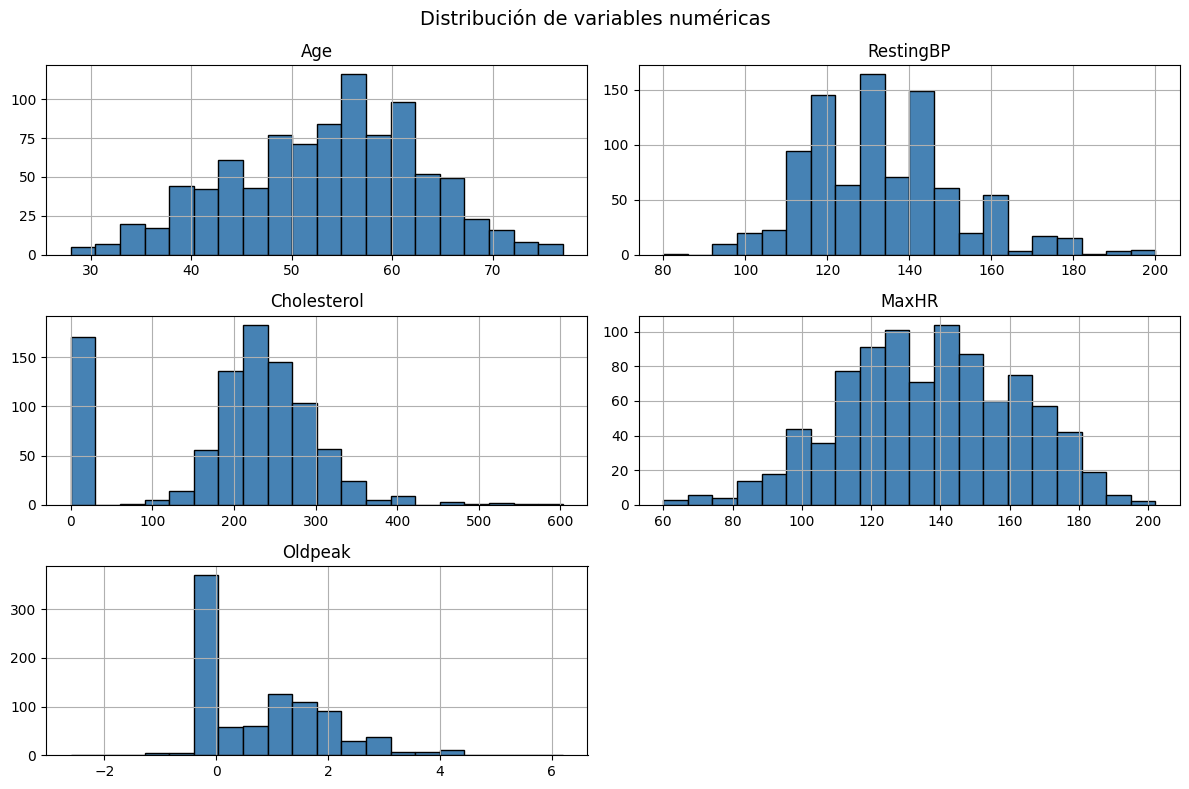

In [9]:
numericas = df.select_dtypes(include='number').drop(columns=['HeartDisease', 'FastingBS']).columns

df[numericas].hist(bins=20, figsize=(12, 8), color='steelblue', edgecolor='black')
plt.suptitle("Distribución de variables numéricas", fontsize=14)
plt.tight_layout()
plt.show()

Se observa que la variable `age` la mayoria de personas se concentran entre 50 y 65 años. `RestingBP` va desde 90 hasta 180 presentando picos en 120, 130 y 145. El `cholesterol` tiene varios pacientes con colesterol 0, sin embargo, como se vio anteriormente esto se puede tratar de un error y se imputaran con la mediana en el preprocesamiento, tambien este se concentra entre 190 y 260. La `MaxHr` presenta una distrbucion aparantemente normal yendo desde centrandose entre 120 y 170 pulsaciones

### Variables Categoricas

Se analizan las frecuencias de cada variable categorica para poder entender como estan compuestas. 

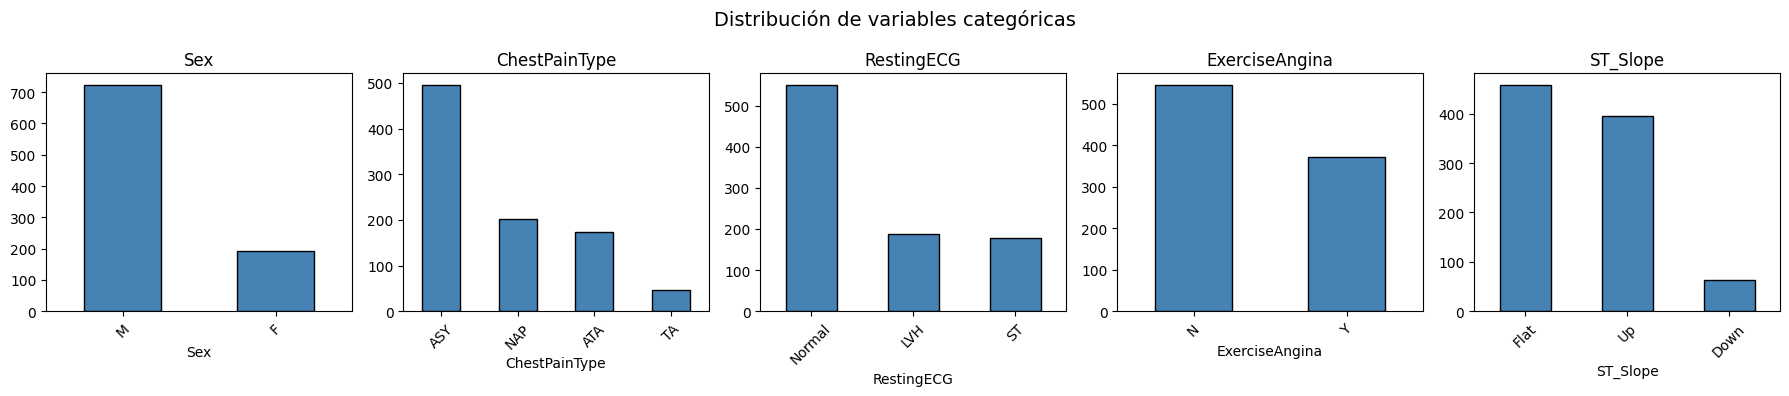

In [10]:
categoricas = df.select_dtypes(include='object').columns

fig, axes = plt.subplots(1, len(categoricas), figsize=(18, 4))
for i, col in enumerate(categoricas):
    df[col].value_counts().plot(kind='bar', ax=axes[i], color='steelblue', edgecolor='black')
    axes[i].set_title(col)
    axes[i].tick_params(axis='x', rotation=45)
plt.suptitle("Distribución de variables categóricas", fontsize=14)
plt.tight_layout()
plt.show()

El dataset presenta un desbalance la variable  `Sex`, con aproximadamente 725 hombres frente a 190 mujeres. En `ChestPainType`, la categoría ASY (asintomático) es la más frecuente con cerca de 500 casos, lo cual es relevante debido a que  este tipo de dolor es el más asociado a enfermedad cardíaca silenciosa. `RestingECG` muestra que la mayoría de pacientes tienen resultado Normal, seguido de LVH y ST en proporciones similares. `ExerciseAngina` indica que la mayoría no presenta angina al ejercitarse. `ST_Slope` muestra que Flat y Up son las  más comunes, siendo Down la menos frecuente 

## Analisis Multivariado

### Boxpolot por clase

Se compara la distribucion de cada variable numerica entre pacientes con enfermedad cardiaca (1) y sin ella (0)

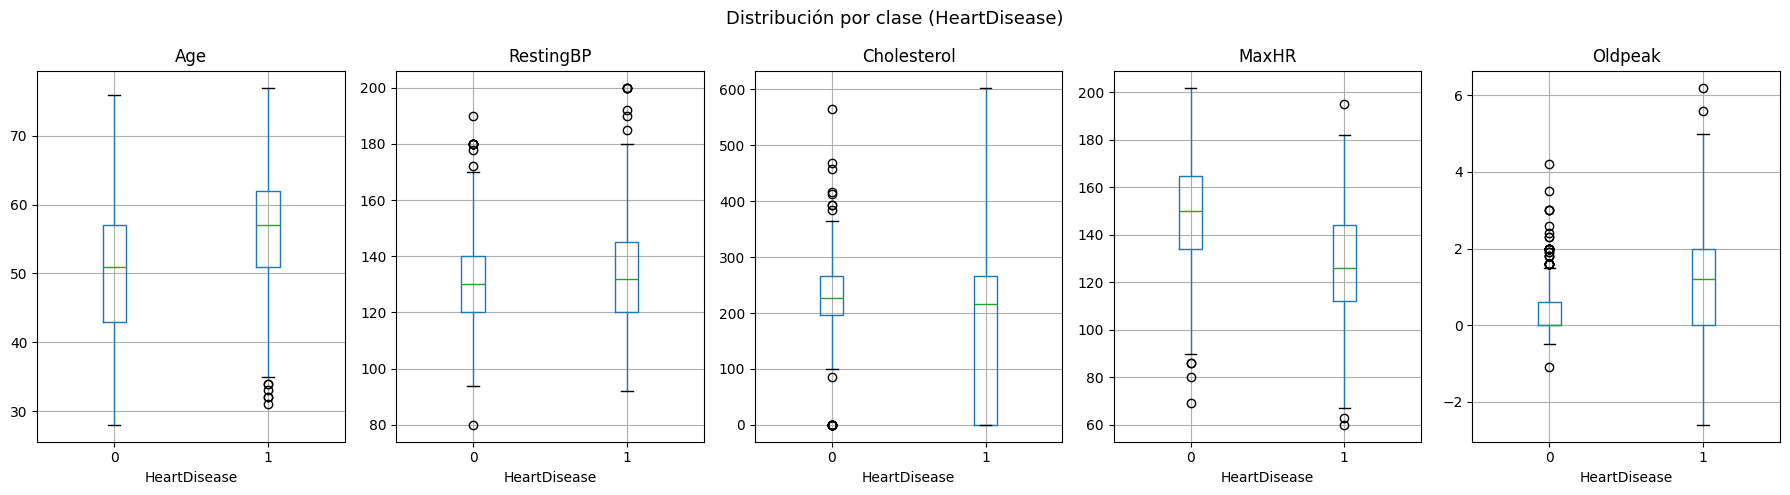

In [11]:
numericas = df.select_dtypes(include='number').drop(columns=['HeartDisease', 'FastingBS']).columns

fig, axes = plt.subplots(1, len(numericas), figsize=(18, 5))
for i, col in enumerate(numericas):
    df.boxplot(column=col, by='HeartDisease', ax=axes[i])
    axes[i].set_title(col)
    axes[i].set_xlabel('HeartDisease')
plt.suptitle("Distribución por clase (HeartDisease)", fontsize=13)
plt.tight_layout()
plt.show()

Los boxplots muestran diferencias claras entre pacientes con y sin enfermedad cardíaca. `Age` indica que los pacientes enfermos (1) son en promedio mayores, con mediana de 57 años frente a 51 en sanos (0), y se observan valores atípicos en edades menores a 35 años. `RestingBP` no muestra una separación clara entre clases, con medianas similares alrededor de 130 en ambos. `Cholesterol` tampoco se puede diferenciar bien. En `MaxHR` se puede ver una separación entre los pacientes sanos que alcanzan frecuencias cardíacas maximas más altas (mediana alrededor 150) comparado con los enfermos (mediana alrededor de 130). `Oldpeak` los enfermos presentan valores más altos, mientras que los no enfermos cuentan con mas valores atipicos por arriba de 1

### Correlacion

Matriz de correlacion entre numericas y variable objetivo

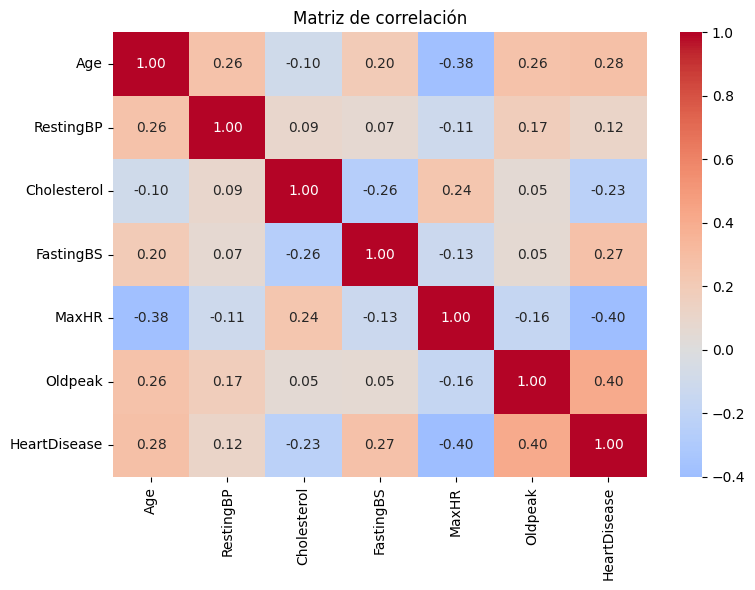

In [ ]:
corr = df.select_dtypes(include='number').corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot =True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Matriz de correlación")
plt.tight_layout()
plt.show()

La matriz de correlación muesta que `MaxHR` tiene la correlación negativa más fuerte con `HeartDisease` (-0.40), confirmando que a mayor frecuencia cardíaca máxima menor riesgo. `Oldpeak` tiene la correlación positiva más alta (0.40). `Age` también correlaciona positivamente (0.28) y `Cholesterol` negativamente (-0.23), aunque este puede estar sesgado por los 0